In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../../data/preprocessed/imputed_data.csv')

feature_cols = [col for col in df.columns if col not in
                ["result_match", "stage", "season", "date", "home_team", "away_team"]]

X_= df[["match_api_id", "stage", "season", "date", "home_team", "away_team"]].copy()

y = df[['result_match']]
X = df[feature_cols].copy()


def freedman_diaconis_bins(series):
    """
    Calculate the optimal number of bins using the Freedman-Diaconis rule.
    """
    data = series.dropna()

    q25, q75 = np.percentile(data, [5, 95])
    iqr = q75 - q25

    bin_width = 2 * iqr / np.cbrt(len(data))

    if bin_width == 0:
        return 10

    data_range = data.max() - data.min()
    n_bins = int(np.ceil(data_range / bin_width))
    return n_bins

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2978 entries, 0 to 2977
Data columns (total 52 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   match_api_id                                   2978 non-null   int64  
 1   result_match                                   2978 non-null   int64  
 2   stage                                          2978 non-null   int64  
 3   season                                         2978 non-null   object 
 4   date                                           2978 non-null   object 
 5   home_team                                      2978 non-null   int64  
 6   away_team                                      2978 non-null   int64  
 7   points_home                                    2978 non-null   float64
 8   points_away                                    2978 non-null   float64
 9   home_last_team_goal                            2978 

In [2]:
n_bins_home_last_team_possession = freedman_diaconis_bins(X['home_last_team_possession'])
n_bins_away_last_team_possession = freedman_diaconis_bins(X['away_last_team_possession'])
n_bins_rolling_avg_goals_home = freedman_diaconis_bins(X['rolling_avg_goals_home'])
n_bins_rolling_avg_goals_away = freedman_diaconis_bins(X['rolling_avg_goals_away'])
n_bins_rolling_avg_goals_conversion_rate_away = freedman_diaconis_bins(X['rolling_avg_goals_conversion_rate_away'])
n_bins_rolling_avg_goals_conversion_rate_diff = freedman_diaconis_bins(X['rolling_avg_goals_conversion_rate_diff'])
n_bins_rolling_avg_shoton_home = freedman_diaconis_bins(X['rolling_avg_shoton_home'])
n_bins_rolling_avg_shoton_away = freedman_diaconis_bins(X['rolling_avg_shoton_away'])
n_bins_team_acceleration_home = freedman_diaconis_bins(X['team_acceleration_home'])
n_bins_goal_conversion_rate_home = freedman_diaconis_bins(X['goal_conversion_rate_home'])
n_bins_rolling_stability_goal_away = freedman_diaconis_bins(X['rolling_stability_goal_away'])
n_bins_rolling_stability_goals_conversion_rate_home = freedman_diaconis_bins(X['rolling_stability_goals_conversion_rate_home'])
n_bins_rolling_stability_goals_conversion_rate_away = freedman_diaconis_bins(X['rolling_stability_goals_conversion_rate_away'])
n_bins_rolling_stability_goals_conversion_rate_diff = freedman_diaconis_bins(X['rolling_stability_goals_conversion_rate_diff'])
n_bins_rolling_stability_shoton_away = freedman_diaconis_bins(X['rolling_stability_shoton_away'])
n_bins_rolling_stability_shoton_diff = freedman_diaconis_bins(X['rolling_stability_shoton_diff'])
n_bins_points_diff = freedman_diaconis_bins(X['points_diff'])
n_bins_points_ratio = freedman_diaconis_bins(X['points_ratio'])

print(f"Optimal bins for home_last_team_possession: {n_bins_home_last_team_possession}")
print(f"Optimal bins for away_last_team_possession: {n_bins_away_last_team_possession}")
print(f"Optimal bins for rolling_avg_goals_home: {n_bins_rolling_avg_goals_home}")
print(f"Optimal bins for rolling_avg_goals_away: {n_bins_rolling_avg_goals_away}")
print(f"Optimal bins for rolling_avg_goals_conversion_rate_away: {n_bins_rolling_avg_goals_conversion_rate_away}")
print(f"Optimal bins for rolling_avg_goals_conversion_rate_diff: {n_bins_rolling_avg_goals_conversion_rate_diff}")
print(f"Optimal bins for rolling_avg_shoton_home: {n_bins_rolling_avg_shoton_home}")
print(f"Optimal bins for rolling_avg_shoton_away: {n_bins_rolling_avg_shoton_away}")
print(f"Optimal bins for team_acceleration_home: {n_bins_team_acceleration_home}")
print(f"Optimal bins for goal_conversion_rate_home: {n_bins_goal_conversion_rate_home}")
print(f"Optimal bins for rolling_stability_goal_away: {n_bins_rolling_stability_goal_away}")
print(f"Optimal bins for rolling_stability_goals_conversion_rate_home: {n_bins_rolling_stability_goals_conversion_rate_home}")
print(f"Optimal bins for rolling_stability_goals_conversion_rate_away: {n_bins_rolling_stability_goals_conversion_rate_away}")
print(f"Optimal bins for rolling_stability_goals_conversion_rate_diff: {n_bins_rolling_stability_goals_conversion_rate_diff}")
print(f"Optimal bins for rolling_stability_shoton_away: {n_bins_rolling_stability_shoton_away}")
print(f"Optimal bins for rolling_stability_shoton_diff: {n_bins_rolling_stability_shoton_diff}")
print(f"Optimal bins for points_diff: {n_bins_points_diff}")
print(f"Optimal bins for points_ratio: {n_bins_points_ratio}")

X['n_bins_home_last_team_possession'] = pd.cut(X['home_last_team_possession'], bins=n_bins_home_last_team_possession).cat.codes
X['n_bins_away_last_team_possession'] = pd.cut(X['away_last_team_possession'], bins=n_bins_away_last_team_possession).cat.codes
X['n_bins_rolling_avg_goals_home'] = pd.cut(X['rolling_avg_goals_home'], bins=n_bins_rolling_avg_goals_home).cat.codes
X['n_bins_rolling_avg_goals_away'] = pd.cut(X['rolling_avg_goals_away'], bins=n_bins_rolling_avg_goals_away).cat.codes
X['n_bins_rolling_avg_goals_conversion_rate_away'] = pd.cut(X['rolling_avg_goals_conversion_rate_away'], bins=n_bins_rolling_avg_goals_conversion_rate_away).cat.codes
X['n_bins_rolling_avg_goals_conversion_rate_diff'] = pd.cut(X['rolling_avg_goals_conversion_rate_diff'], bins=n_bins_rolling_avg_goals_conversion_rate_diff).cat.codes
X['n_bins_rolling_avg_shoton_home'] = pd.cut(X['rolling_avg_shoton_home'], bins=n_bins_rolling_avg_shoton_home).cat.codes
X['n_bins_rolling_avg_shoton_away'] = pd.cut(X['rolling_avg_shoton_away'], bins=n_bins_rolling_avg_shoton_away).cat.codes
X['n_bins_team_acceleration_home'] = pd.cut(X['team_acceleration_home'], bins=n_bins_team_acceleration_home).cat.codes
X['n_bins_goal_conversion_rate_home'] = pd.cut(X['goal_conversion_rate_home'], bins=n_bins_goal_conversion_rate_home).cat.codes
X['n_bins_rolling_stability_goal_away'] = pd.cut(X['rolling_stability_goal_away'], bins=n_bins_rolling_stability_goal_away).cat.codes
X['n_bins_rolling_stability_goals_conversion_rate_home'] = pd.cut(X['rolling_stability_goals_conversion_rate_home'], bins=n_bins_rolling_stability_goals_conversion_rate_home).cat.codes
X['n_bins_rolling_stability_goals_conversion_rate_away'] = pd.cut(X['rolling_stability_goals_conversion_rate_away'], bins=n_bins_rolling_stability_goals_conversion_rate_away).cat.codes
X['n_bins_rolling_stability_goals_conversion_rate_diff'] = pd.cut(X['rolling_stability_goals_conversion_rate_diff'], bins=n_bins_rolling_stability_goals_conversion_rate_diff).cat.codes
X['n_bins_rolling_stability_shoton_away'] = pd.cut(X['rolling_stability_shoton_away'], bins=n_bins_rolling_stability_shoton_away).cat.codes
X['n_bins_rolling_stability_shoton_diff'] = pd.cut(X['rolling_stability_shoton_diff'], bins=n_bins_rolling_stability_shoton_diff).cat.codes
X['n_bins_points_diff'] = pd.cut(X['points_diff'], bins=n_bins_points_diff).cat.codes
X['n_bins_points_ratio'] = pd.cut(X['points_ratio'], bins=n_bins_points_ratio).cat.codes

Optimal bins for home_last_team_possession: 15
Optimal bins for away_last_team_possession: 19
Optimal bins for rolling_avg_goals_home: 18
Optimal bins for rolling_avg_goals_away: 15
Optimal bins for rolling_avg_goals_conversion_rate_away: 34
Optimal bins for rolling_avg_goals_conversion_rate_diff: 34
Optimal bins for rolling_avg_shoton_home: 18
Optimal bins for rolling_avg_shoton_away: 18
Optimal bins for team_acceleration_home: 14
Optimal bins for goal_conversion_rate_home: 40
Optimal bins for rolling_stability_goal_away: 15
Optimal bins for rolling_stability_goals_conversion_rate_home: 35
Optimal bins for rolling_stability_goals_conversion_rate_away: 35
Optimal bins for rolling_stability_goals_conversion_rate_diff: 39
Optimal bins for rolling_stability_shoton_away: 18
Optimal bins for rolling_stability_shoton_diff: 18
Optimal bins for points_diff: 17
Optimal bins for points_ratio: 25


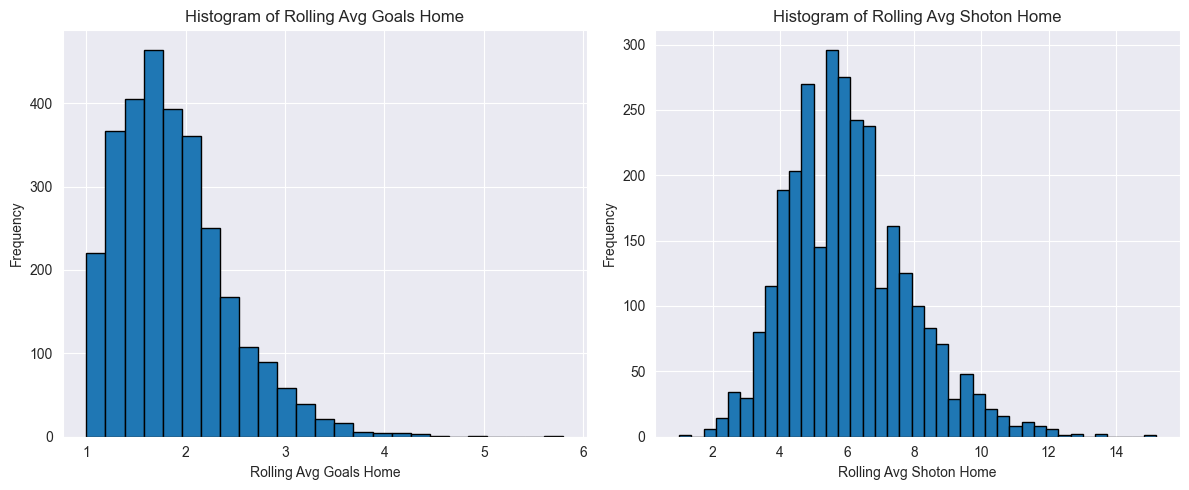

In [3]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df['rolling_avg_goals_home'].dropna(), bins=n_bins_points_ratio, edgecolor='black')
plt.title('Histogram of Rolling Avg Goals Home')
plt.xlabel('Rolling Avg Goals Home')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(df['rolling_avg_shoton_home'].dropna(), bins=n_bins_rolling_stability_goals_conversion_rate_diff, edgecolor='black')
plt.title('Histogram of Rolling Avg Shoton Home')
plt.xlabel('Rolling Avg Shoton Home')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [4]:
drop = ['home_last_team_possession',
                                  'rolling_avg_goals_home',
                                  'rolling_avg_shoton_home',
                                  'away_last_team_possession',
                                  'team_acceleration_home',
                                  'goal_conversion_rate_home',
                                  'rolling_stability_goals_conversion_rate_home',
                                  'rolling_avg_goals_away',
                                  'rolling_stability_goal_away',
                                  'rolling_avg_goals_conversion_rate_away',
                                  'rolling_stability_goals_conversion_rate_away',
                                  'rolling_avg_shoton_away',
                                  'rolling_stability_shoton_away',
                                  'rolling_avg_goals_conversion_rate_diff',
                                  'rolling_stability_goals_conversion_rate_diff',
                                  'rolling_stability_shoton_diff',
                                  'points_diff',
                                  'points_ratio',
                                  ]
X.drop(drop, axis=1, inplace=True)

In [5]:
X['result_match']=y
X = pd.merge(X, X_, on='match_api_id')
X.to_csv('../../data/preprocessed/X_binned.csv', index=False)
X

,match_api_id,points_home,points_away,home_last_team_goal,home_last_team_shoton,away_last_team_goal,away_last_team_shoton,team_strength_home,team_strength_away,strength_difference,...,n_bins_rolling_stability_shoton_away,n_bins_rolling_stability_shoton_diff,n_bins_points_diff,n_bins_points_ratio,result_match,stage,season,date,home_team,away_team
0,489063,3.0,4.0,1.00,12.0,1.000000,1.0,78.318182,67.545455,10.772727,...,4,10,8,2,1,3,2008/2009,2008-08-30,9825,10261
1,489065,3.0,4.0,2.00,5.0,1.000000,8.0,65.136364,79.681818,-14.545455,...,4,10,8,2,1,3,2008/2009,2008-08-30,8654,8655
2,489068,3.0,3.0,1.00,7.0,3.000000,1.0,63.924242,70.363636,-6.439394,...,4,10,8,3,1,3,2008/2009,2008-08-30,8549,10194
3,489069,3.0,0.0,3.00,5.0,1.000000,2.0,71.318182,57.818182,13.500000,...,3,10,9,0,0,3,2008/2009,2008-08-30,8559,8659
4,489070,4.0,0.0,1.00,5.0,1.000000,7.0,63.318182,71.681818,-8.363636,...,4,10,9,0,0,3,2008/2009,2008-08-30,8667,8528
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2973,1987599,44.0,34.0,1.00,4.0,4.000000,6.0,72.327273,52.127273,20.200000,...,4,9,10,4,1,38,2015/2016,2016-05-15,8668,9850
2974,1987598,49.0,80.0,2.00,5.0,3.000000,4.0,65.445455,64.163636,1.281818,...,3,8,3,2,0,38,2015/2016,2016-05-15,8455,8197
2975,1987597,68.0,17.0,2.00,7.0,1.666667,1.0,70.627273,78.745455,-8.118182,...,7,9,16,14,1,38,2015/2016,2016-05-15,9825,10252
2976,1987601,34.0,70.0,1.75,6.0,1.000000,6.0,79.690909,72.009091,7.681818,...,1,11,2,1,1,38,2015/2016,2016-05-15,10261,8586


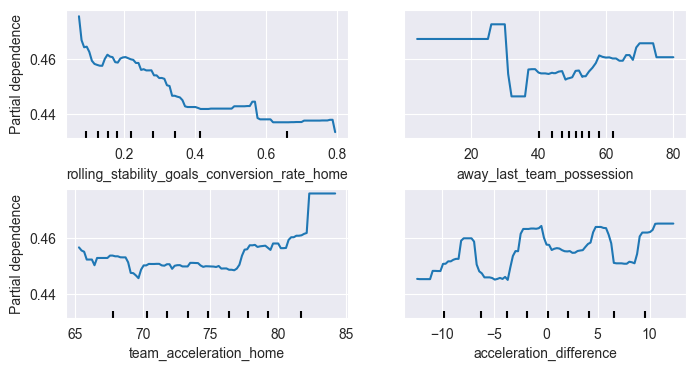

In [4]:
from src.eda.PartialDependencyAnalyzer import PartialDependenceAnalyzer

analyzer_pdp = PartialDependenceAnalyzer(
    features=[
        'rolling_stability_goals_conversion_rate_home', 'away_last_team_possession', 'team_acceleration_home', 'acceleration_difference'
    ],
    model_params={
        'max_depth': 5,
        'n_estimators': 400
    },
    threshold=0.49,
    plot_type='average'

)

analyzer_pdp.fit_and_visualize(X, y, )

In [5]:
potential_features_for_binning = ['home_last_team_possession', # [<40], [40–70], [>70]
                                  'rolling_avg_goals_home',  # [<1,5], [1,5-2,5], [2,5<]
                                  'rolling_avg_shoton_home',  # [<5], [5-6,4], [6,4<]
                                  'away_last_team_possession',  # [<40], [40–50], [50–60], [>60]
                                  'team_acceleration_home',  # [<70], [70–75], [75–82], [>82]
                                  'goal_conversion_rate_home',  # [<0,2], [0,2-0,6], [0,6<]
                                  'rolling_stability_goals_conversion_rate_home',  # [>0,2], [0,2-0,4], [0,4<]
                                  'rolling_avg_goals_away',  # [<1,5], [1,5-2], [2-2,5], [2,5<]
                                  'rolling_stability_goal_away',  # [0-0,5], [0,5-1], [1<]
                                  'rolling_avg_goals_conversion_rate_away',  # [<0,35], [0,35-0,45], [0,45<]
                                  'rolling_stability_goals_conversion_rate_away', # [<0,1], [0,1-0,37], [0,37<0,6], [0,6<]
                                  'rolling_avg_shoton_away',  # [<5,5], [5,5-6,5], [6,5<]
                                  'rolling_stability_shoton_away',  # [<1,5], [1,5-4,2], [4,2<]
                                  'rolling_avg_goals_conversion_rate_diff', # [<-0.2], [-0.2 - 0], [0 - 0.2], [>0.2]
                                  'rolling_stability_goals_conversion_rate_diff', # [<-0,25], [-0,25-0], [0-0,25<], [0,25<]
                                  'rolling_stability_shoton_diff',  # [<-1], [-1 - 0], [-0<1], [1<]
                                  'points_diff',  # [<-15 - -5], [-5 - 10], [10 < 20], [20<]
                                  'points_ratio',  # [<1,25], [1,25 - 1,75], [1,75 < ]
                                  ]

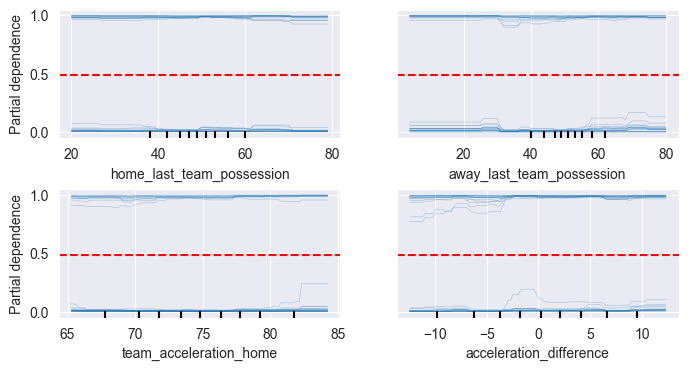

In [6]:
analyzer_ice = PartialDependenceAnalyzer(
    features=[
        'home_last_team_possession', 'away_last_team_possession', 'team_acceleration_home', 'acceleration_difference'
    ],
    model_params={
        'max_depth': 5,
        'n_estimators': 400
    },
    threshold=0.49,
    plot_type='individual'
)

analyzer_ice.fit_and_visualize(X, y, )

In [7]:
def bin_features(df):
    df_ = df.copy()
    binning_dict = {
        'home_last_team_possession': [-np.inf, 0, 40, 70, np.inf],
        'rolling_avg_goals_home': [-np.inf, 0, 1.5, 2.5, np.inf],
        'rolling_avg_shoton_home': [-np.inf, 0, 5, 6.4, np.inf],
        'away_last_team_possession': [-np.inf, 0, 40, 50, 60, np.inf],
        'team_acceleration_home': [-np.inf, 0, 70, 75, 82, np.inf],
        'goal_conversion_rate_home': [-np.inf, 0, 0.2, 0.6, np.inf],
        'rolling_stability_goals_conversion_rate_home': [-np.inf, 0.2, 0.4, np.inf],
        'rolling_avg_goals_away': [-np.inf, 0, 1.5, 2, 2.5, np.inf],
        'rolling_stability_goal_away': [-np.inf, 0, 0.5, 1, np.inf],
        'rolling_avg_goals_conversion_rate_away': [-np.inf, 0, 0.35, 0.45, np.inf],
        'rolling_stability_goals_conversion_rate_away': [-np.inf, 0, 0.1, 0.37, 0.6, np.inf],
        'rolling_avg_shoton_away': [-np.inf, 0, 5.5, 6.5, np.inf],
        'rolling_stability_shoton_away': [-np.inf, 0, 1.5, 4.2, np.inf],
        'rolling_avg_goals_conversion_rate_diff': [-np.inf, -0.2, 0, 0.2, np.inf],
        'rolling_stability_goals_conversion_rate_diff': [-np.inf, -0.25, 0, 0.25, np.inf],
        'rolling_stability_shoton_diff': [-np.inf, -1, 0, 1, np.inf],
        'points_diff': [-np.inf, -15, -5, 10, 20, np.inf],
        'points_ratio': [-np.inf,0, 1.25, 1.75, np.inf]
    }

    for feature, bins in binning_dict.items():
        df_[feature + '_binned'] = pd.cut(df_[feature], bins=bins, labels=False)
        df_ = df_.drop(feature, axis=1)

    return df_

In [8]:
X_binned = bin_features(X)
X_binned

,match_api_id,points_home,points_away,home_last_team_goal,home_last_team_shoton,away_last_team_goal,away_last_team_shoton,team_strength_home,team_strength_away,strength_difference,...,rolling_stability_goal_away_binned,rolling_avg_goals_conversion_rate_away_binned,rolling_stability_goals_conversion_rate_away_binned,rolling_avg_shoton_away_binned,rolling_stability_shoton_away_binned,rolling_avg_goals_conversion_rate_diff_binned,rolling_stability_goals_conversion_rate_diff_binned,rolling_stability_shoton_diff_binned,points_diff_binned,points_ratio_binned
0,489063,3.0,4.0,1.00,12.0,1.000000,1.0,78.318182,67.545455,10.772727,...,0,3,3,1,2,0,2,2,2,1
1,489065,3.0,4.0,2.00,5.0,1.000000,8.0,65.136364,79.681818,-14.545455,...,0,1,1,3,2,3,2,2,2,1
2,489068,3.0,3.0,1.00,7.0,3.000000,1.0,63.924242,70.363636,-6.439394,...,2,3,3,1,2,0,2,2,2,1
3,489069,3.0,0.0,3.00,5.0,1.000000,2.0,71.318182,57.818182,13.500000,...,0,3,2,1,2,2,2,2,2,0
4,489070,4.0,0.0,1.00,5.0,1.000000,7.0,63.318182,71.681818,-8.363636,...,0,1,1,3,2,2,2,2,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2973,1987599,44.0,34.0,1.00,4.0,4.000000,6.0,72.327273,52.127273,20.200000,...,3,3,2,2,2,1,3,2,2,2
2974,1987598,49.0,80.0,2.00,5.0,3.000000,4.0,65.445455,64.163636,1.281818,...,3,2,2,2,2,2,1,1,0,1
2975,1987597,68.0,17.0,2.00,7.0,1.666667,1.0,70.627273,78.745455,-8.118182,...,2,3,4,1,2,0,0,2,4,3
2976,1987601,34.0,70.0,1.75,6.0,1.000000,6.0,79.690909,72.009091,7.681818,...,3,1,2,2,1,3,3,3,0,1


In [9]:
X_binned['result_match']=y
X_binned = pd.merge(X_binned, X_, on='match_api_id')
X_binned.to_csv('../../data/preprocessed/X_binned.csv', index=False)
X_binned

,match_api_id,points_home,points_away,home_last_team_goal,home_last_team_shoton,away_last_team_goal,away_last_team_shoton,team_strength_home,team_strength_away,strength_difference,...,rolling_stability_goals_conversion_rate_diff_binned,rolling_stability_shoton_diff_binned,points_diff_binned,points_ratio_binned,result_match,stage,season,date,home_team,away_team
0,489063,3.0,4.0,1.00,12.0,1.000000,1.0,78.318182,67.545455,10.772727,...,2,2,2,1,1,3,2008/2009,2008-08-30,9825,10261
1,489065,3.0,4.0,2.00,5.0,1.000000,8.0,65.136364,79.681818,-14.545455,...,2,2,2,1,1,3,2008/2009,2008-08-30,8654,8655
2,489068,3.0,3.0,1.00,7.0,3.000000,1.0,63.924242,70.363636,-6.439394,...,2,2,2,1,1,3,2008/2009,2008-08-30,8549,10194
3,489069,3.0,0.0,3.00,5.0,1.000000,2.0,71.318182,57.818182,13.500000,...,2,2,2,0,0,3,2008/2009,2008-08-30,8559,8659
4,489070,4.0,0.0,1.00,5.0,1.000000,7.0,63.318182,71.681818,-8.363636,...,2,2,2,0,0,3,2008/2009,2008-08-30,8667,8528
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2973,1987599,44.0,34.0,1.00,4.0,4.000000,6.0,72.327273,52.127273,20.200000,...,3,2,2,2,1,38,2015/2016,2016-05-15,8668,9850
2974,1987598,49.0,80.0,2.00,5.0,3.000000,4.0,65.445455,64.163636,1.281818,...,1,1,0,1,0,38,2015/2016,2016-05-15,8455,8197
2975,1987597,68.0,17.0,2.00,7.0,1.666667,1.0,70.627273,78.745455,-8.118182,...,0,2,4,3,1,38,2015/2016,2016-05-15,9825,10252
2976,1987601,34.0,70.0,1.75,6.0,1.000000,6.0,79.690909,72.009091,7.681818,...,3,3,0,1,1,38,2015/2016,2016-05-15,10261,8586
